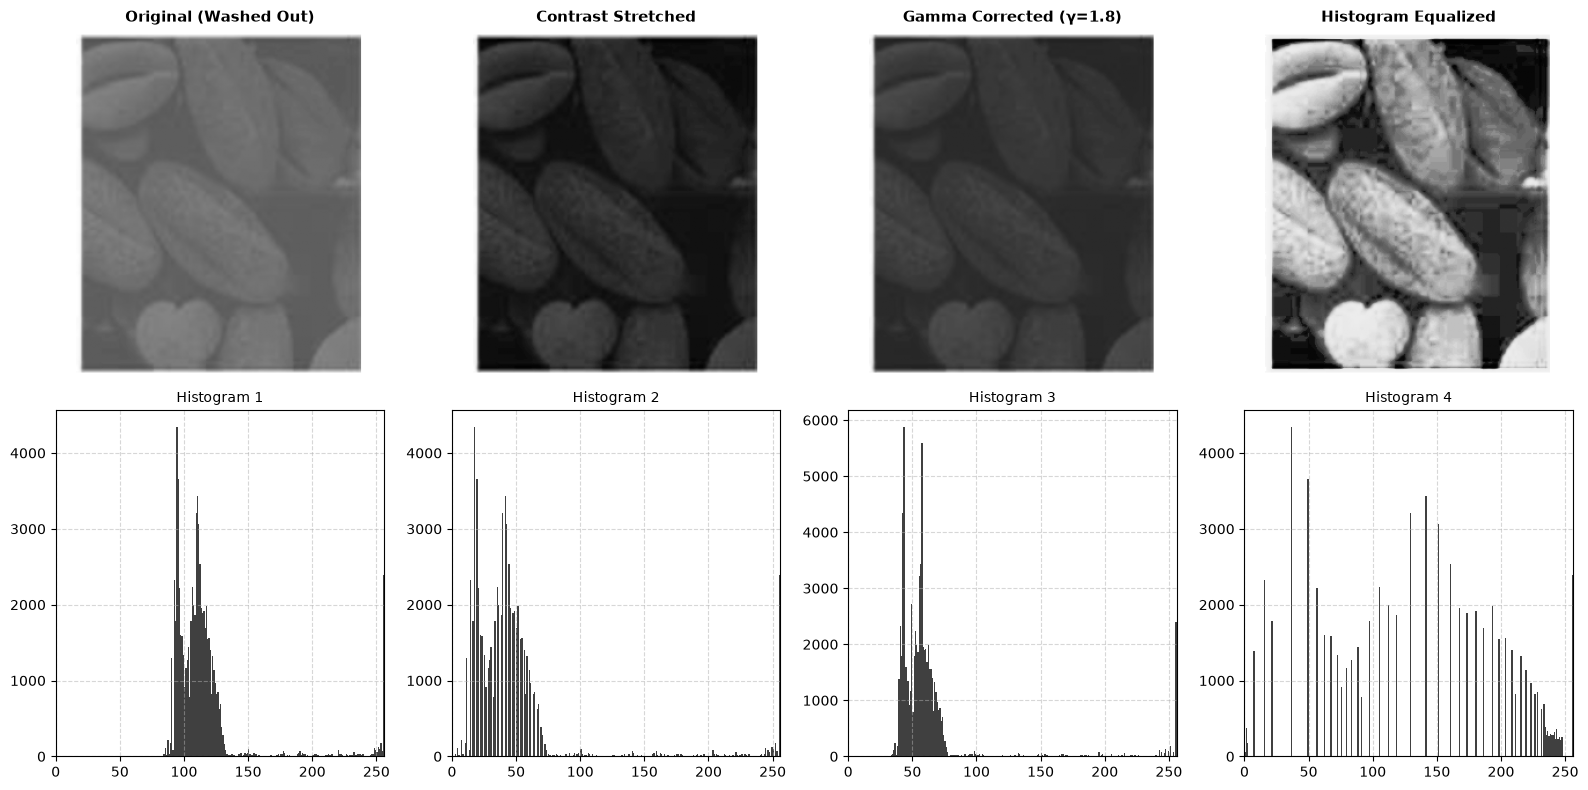

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r'image_1.png' 
src = cv2.imread("C:\\Users\\Dev Radia\\Pictures\\Screenshots\\image1.png", cv2.IMREAD_GRAYSCALE)

if src is None:
    print("Error: Image not found. Check the path!")
    exit()

r_min = np.min(src)
r_max = np.max(src)
stretched = ((src - r_min) / (r_max - r_min) * 255.0).astype(np.uint8)

gamma = 1.8
normalized = src / 255.0
gamma_corrected = np.power(normalized, gamma)
gamma_corrected = np.uint8(gamma_corrected * 255)

hist_equalized = cv2.equalizeHist(src)

titles = ['Original (Washed Out)', 'Contrast Stretched', f'Gamma Corrected (γ={gamma})', 'Histogram Equalized']
images = [src, stretched, gamma_corrected, hist_equalized]

plt.figure(figsize=(16, 8))

for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.axis('off')
    plt.subplot(2, 4, i + 5)
    plt.hist(images[i].ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
    plt.title(f"Histogram {i+1}", fontsize=10)
    plt.xlim([0, 256])
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

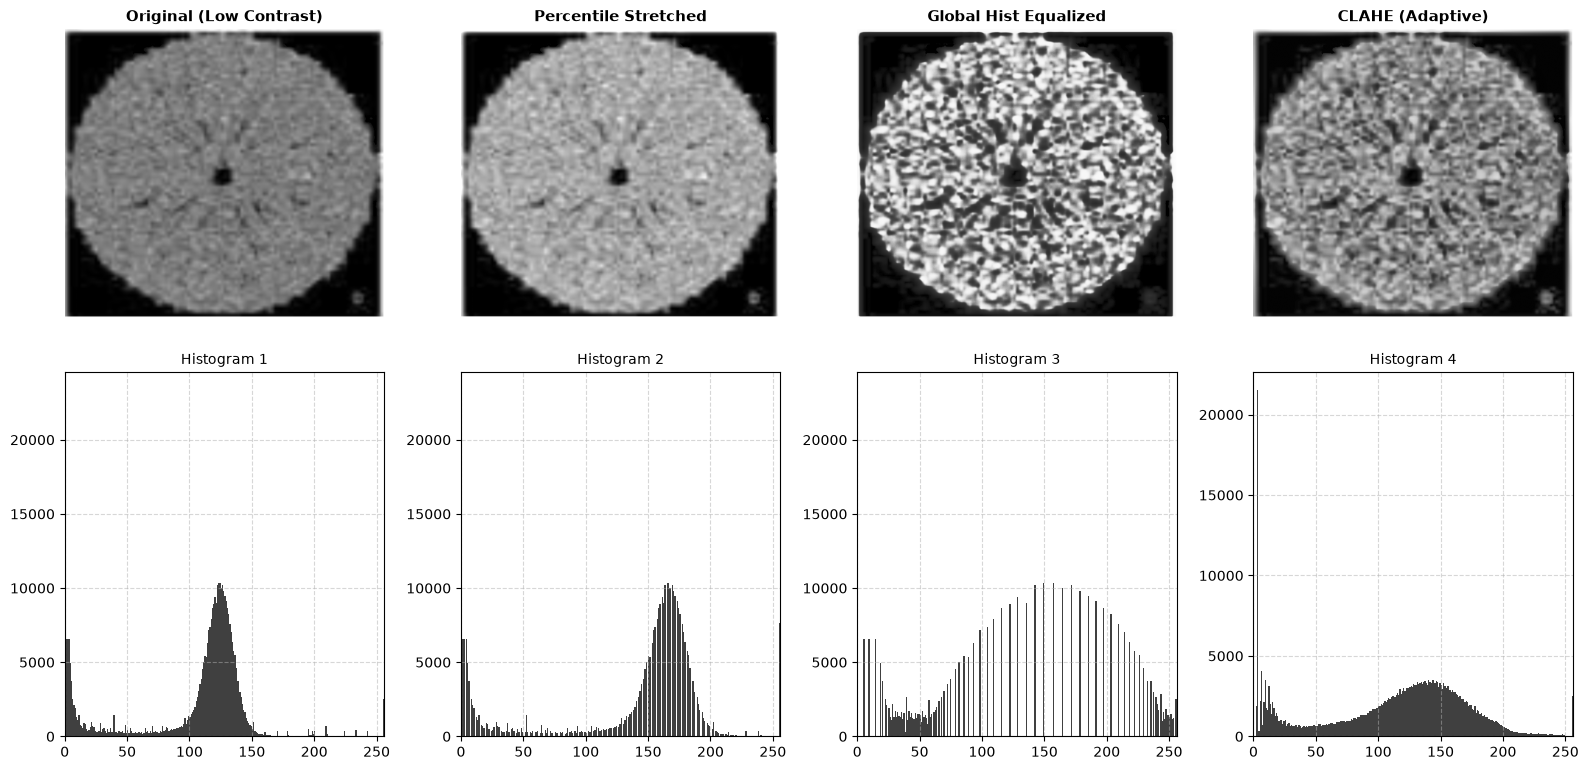

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r'image_2.png'  
src = cv2.imread(r"C:\Users\Dev Radia\Pictures\Screenshots\image2.png", cv2.IMREAD_GRAYSCALE)

p_low, p_high = np.percentile(src, (2, 98))
stretched = np.clip((src - p_low) / (p_high - p_low) * 255.0, 0, 255).astype(np.uint8)

hist_equalized = cv2.equalizeHist(src)

clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
clahe_enhanced = clahe.apply(src)

titles = [
    'Original (Low Contrast)',
    'Percentile Stretched',
    'Global Hist Equalized',
    'CLAHE (Adaptive)'
]
images = [src, stretched, hist_equalized, clahe_enhanced]

plt.figure(figsize=(16, 8))

for i in range(4):
    # Image Display
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.axis('off')

    # Corresponding Histogram
    plt.subplot(2, 4, i + 5)
    plt.hist(images[i].ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
    plt.title(f"Histogram {i+1}", fontsize=10)
    plt.xlim([0, 256])
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\Dev Radia\AppData\Local\Temp\ipykernel_12612\850495886.py:17: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(src) + 1e-5)


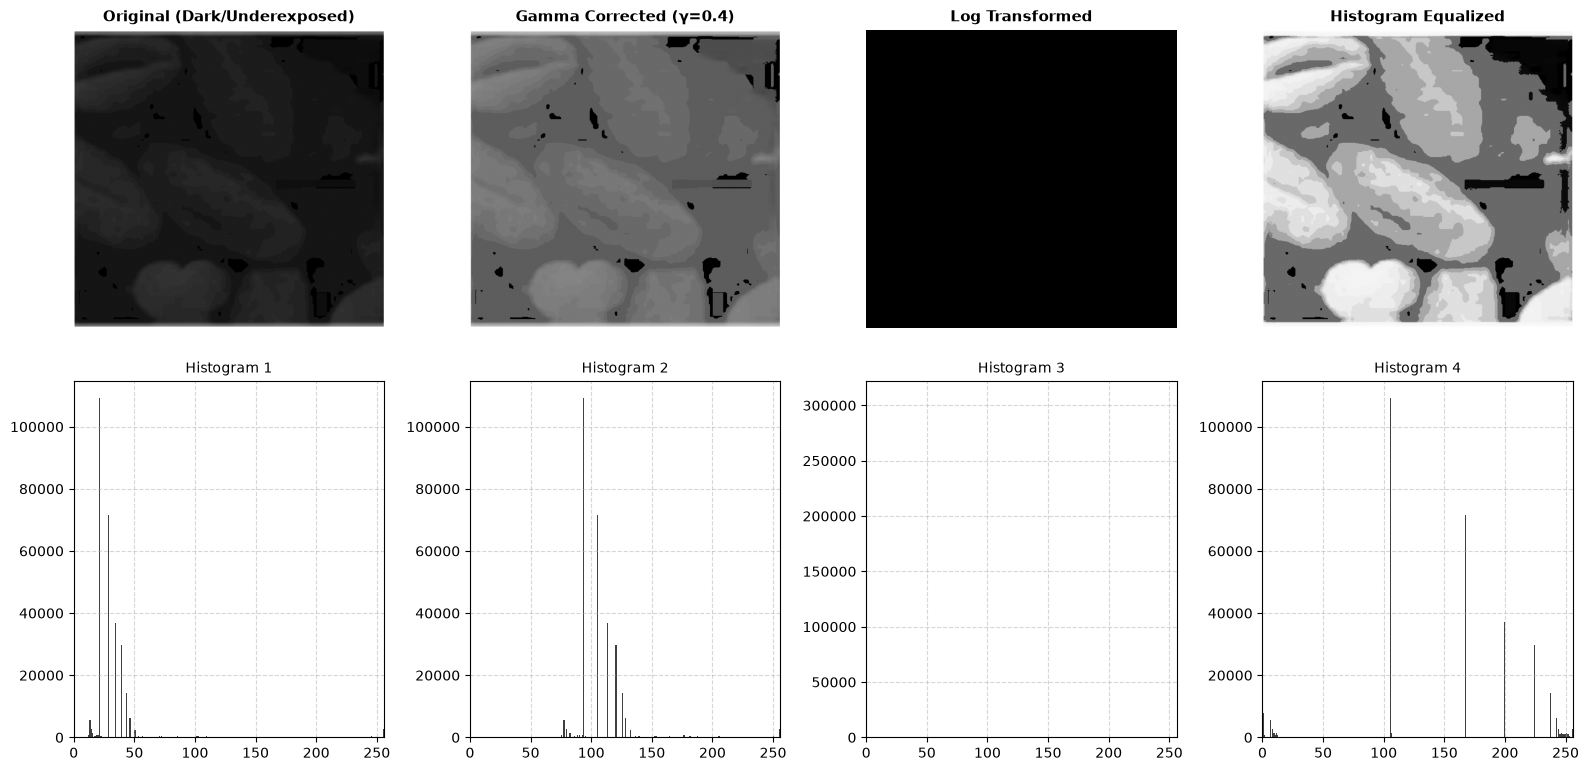

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r'image_3.png'  
src = cv2.imread(r"C:\Users\Dev Radia\Pictures\Screenshots\image3.png", cv2.IMREAD_GRAYSCALE)

if src is None:
    print("Error: Image not found. Check the path!")
    exit()

gamma = 0.4
normalized = src / 255.0
gamma_corrected = np.power(normalized, gamma)
gamma_corrected = np.uint8(gamma_corrected * 255)

c = 255 / np.log(1 + np.max(src) + 1e-5)
log_transformed = c * np.log(1 + src.astype(np.float64))
log_transformed = np.uint8(np.clip(log_transformed, 0, 255))

hist_equalized = cv2.equalizeHist(src)

titles = [
    'Original (Dark/Underexposed)',
    f'Gamma Corrected (γ={gamma})',
    'Log Transformed',
    'Histogram Equalized'
]
images = [src, gamma_corrected, log_transformed, hist_equalized]

plt.figure(figsize=(16, 8))

for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.axis('off')

    plt.subplot(2, 4, i + 5)
    plt.hist(images[i].ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
    plt.title(f"Histogram {i+1}", fontsize=10)
    plt.xlim([0, 256])
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

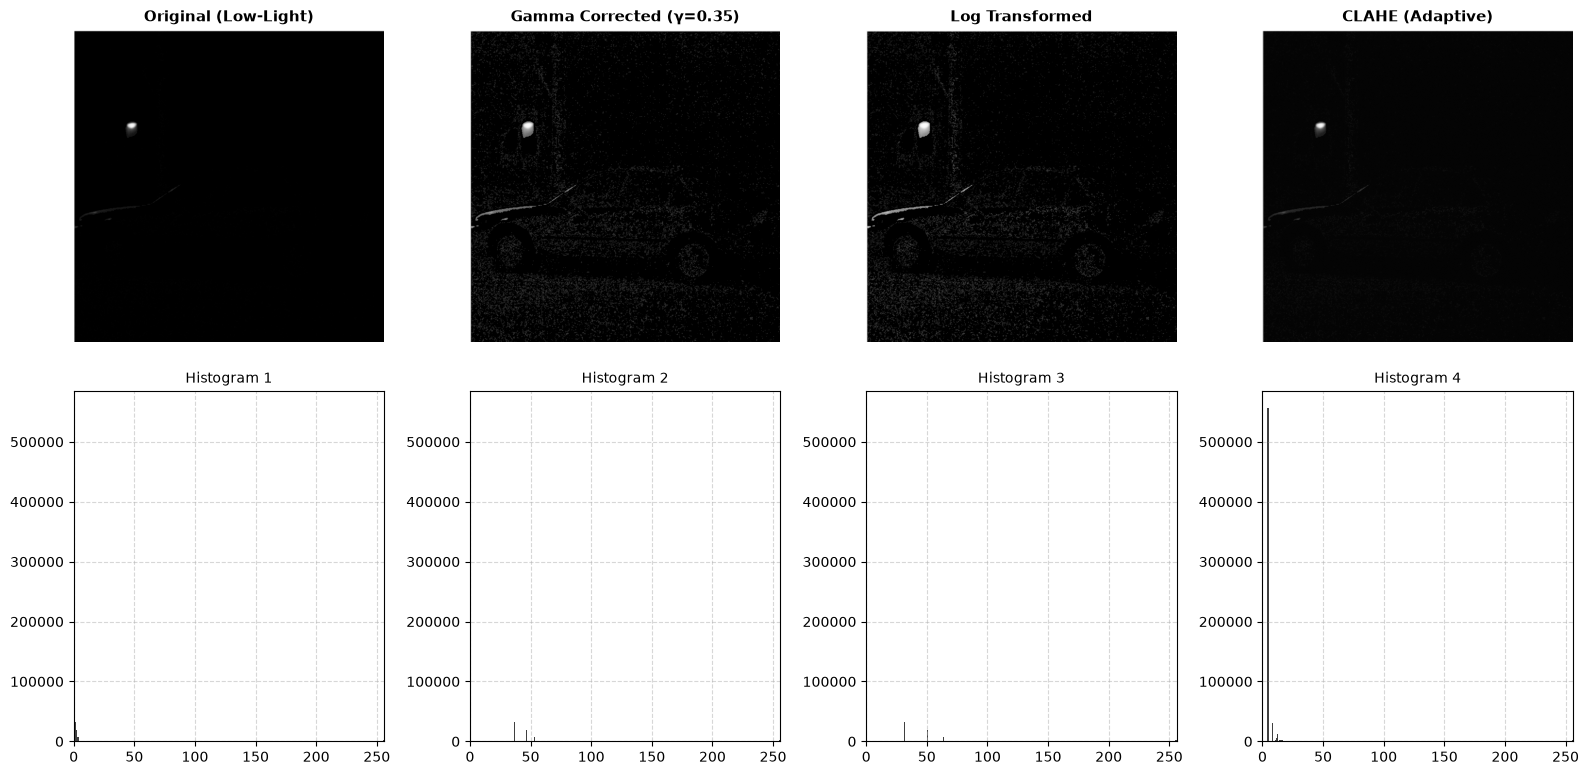

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r'image_4.png' 
src = cv2.imread(r"C:\Users\Dev Radia\Pictures\Screenshots\image4.png", cv2.IMREAD_GRAYSCALE)

gamma = 0.35
normalized = src / 255.0
gamma_corrected = np.power(normalized, gamma)
gamma_corrected = np.uint8(np.clip(gamma_corrected * 255, 0, 255))

c = 255.0 / np.log(1.0 + 255.0)
log_transformed = c * np.log(1.0 + src.astype(np.float64))
log_transformed = np.uint8(np.clip(log_transformed, 0, 255))

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
clahe_enhanced = clahe.apply(src)

titles = [
    'Original (Low-Light)',
    f'Gamma Corrected (γ={gamma})',
    'Log Transformed',
    'CLAHE (Adaptive)'
]
images = [src, gamma_corrected, log_transformed, clahe_enhanced]

plt.figure(figsize=(16, 8))

for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.axis('off')

    plt.subplot(2, 4, i + 5)
    plt.hist(images[i].ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
    plt.title(f"Histogram {i+1}", fontsize=10)
    plt.xlim([0, 256])
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

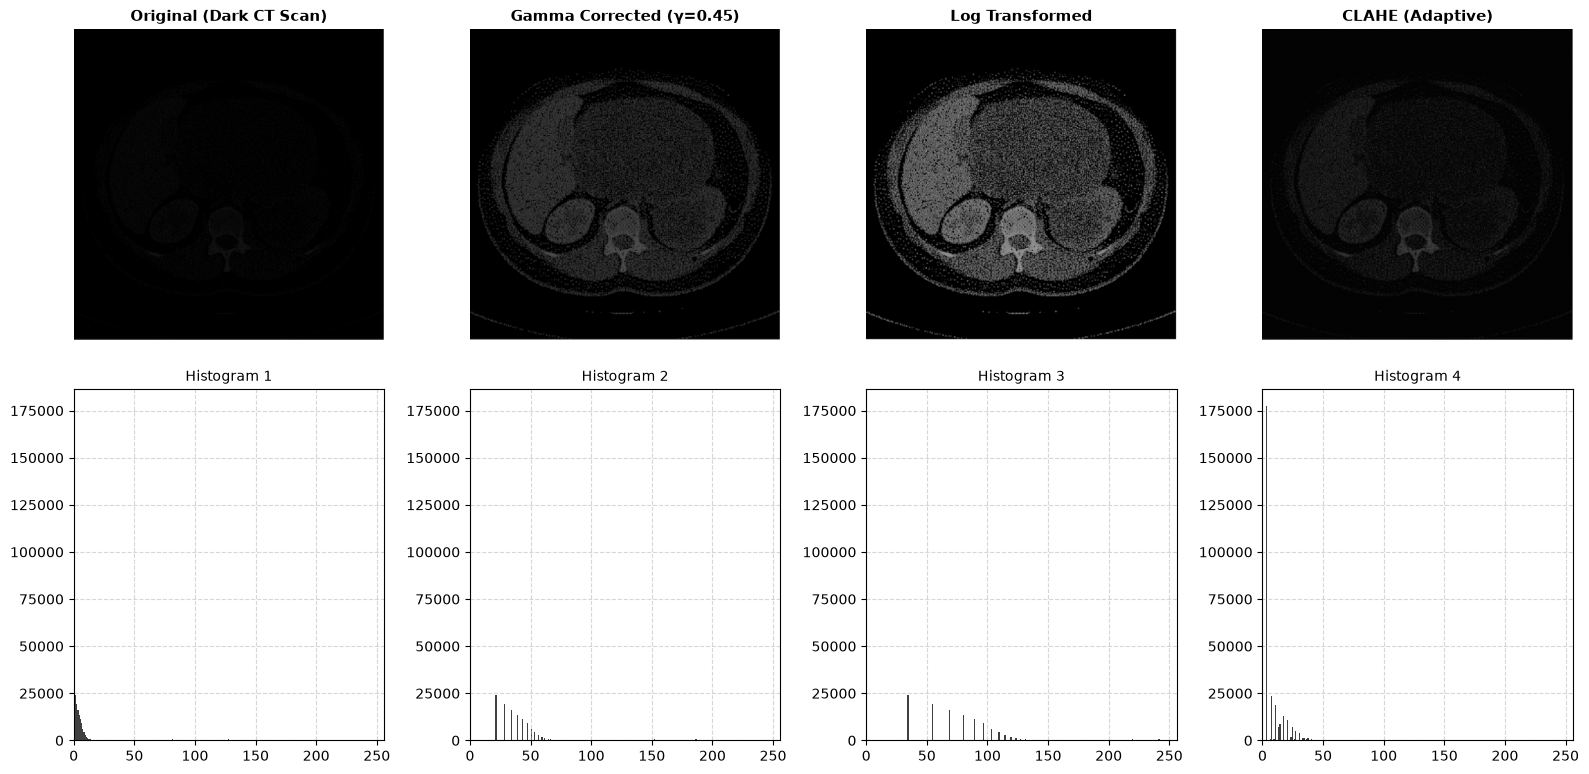

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r'image_5.png'  
src = cv2.imread(r"C:\Users\Dev Radia\Pictures\Screenshots\image5.png", cv2.IMREAD_GRAYSCALE)

gamma = 0.45
normalized = src / 255.0
gamma_corrected = np.power(normalized, gamma)
gamma_corrected = np.uint8(np.clip(gamma_corrected * 255, 0, 255))

c = 255.0 / np.log(1.0 + np.max(src) + 1e-5)
log_transformed = c * np.log(1.0 + src.astype(np.float64))
log_transformed = np.uint8(np.clip(log_transformed, 0, 255))

clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
clahe_enhanced = clahe.apply(src)

titles = [
    'Original (Dark CT Scan)',
    f'Gamma Corrected (γ={gamma})',
    'Log Transformed',
    'CLAHE (Adaptive)'
]
images = [src, gamma_corrected, log_transformed, clahe_enhanced]

plt.figure(figsize=(16, 8))

for i in range(4):
    # Image Display
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.axis('off')

    # Corresponding Histogram
    plt.subplot(2, 4, i + 5)
    plt.hist(images[i].ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
    plt.title(f"Histogram {i+1}", fontsize=10)
    plt.xlim([0, 256])
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()